# Identificação de transações fraudulentas em cartões de crédito utilizando aprendizado de máquina não supervisionado

#### Integrantes do grupo:

* CAIO REBERT OLIVEIRA DA SILVA - 20260001876 
* GABRIEL SOARES DE VASCONCELOS LIRA - 20260001956  
* JADSON VINICIUS RAMOS DE SOUZA - 20230056158  
* SILAS EDUARDO RODRIGUES DOS SANTOS - 20260002167  

#### Importação das libs necessárias:

In [ ]:
# instalação
!pip install pandas scikit-learn matplotlib

# importação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, pairwise_distances, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA


#### Funções utilitárias de limpeza e manipulação dos dados:

In [3]:
def limpar_e_normalizar_csv(caminho_entrada, caminho_saida):
    df = pd.read_csv(caminho_entrada, sep=',', dtype={'zip': str, 'merch_zipcode': str, 'cc_num': str})

    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    if 'trans_date_trans_time' in df.columns:
        df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
        df['trans_hour'] = df['trans_date_trans_time'].dt.hour
        df['trans_day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

    if 'dob' in df.columns:
        df['dob'] = pd.to_datetime(df['dob'])
        df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).round(0)

    colunas_texto = ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job']
    for col in colunas_texto:
        if col in df.columns:
            df[col] = df[col].fillna('não informado').astype(str).str.strip().str.lower()

    if 'city_pop' in df.columns:
        df['city_pop'] = df['city_pop'].fillna(df['city_pop'].median())

    df = df.dropna(subset=['lat', 'long', 'merch_lat', 'merch_long'])

    if 'is_fraud' in df.columns:
        df = df.dropna(subset=['is_fraud'])
        df['is_fraud'] = df['is_fraud'].astype(int)

    df.to_csv(caminho_saida, index=False, encoding='utf-8')
    print("Tratamento avançado para detecção de fraude concluído!")

#### Tratamento dos dados:

In [4]:
try:
    arquivo_sujo = "data/credit_card_transaction_train.csv"
    arquivo_limpo = "data/dados_limpos.csv"
    limpar_e_normalizar_csv(arquivo_sujo, arquivo_limpo)
except FileNotFoundError:
    print(f"Erro: O arquivo '{arquivo_sujo}' não foi encontrado. Altere os caminhos no código.")

Tratamento avançado para detecção de fraude concluído!


#### Exibição de informações sobre os dados:

##### Carregamento dos dados:

In [5]:
# Carregamento dos dados:
df = pd.read_csv("data/dados_limpos.csv", sep=",")

##### Informações do dataframe:

In [6]:
print('# Linhas e Colunas do Dataframe:')
print(df.shape)

print('')

print('# Primeiras linhas do Dataframe:')
df.head(3)

# Linhas e Colunas do Dataframe:
(1296675, 26)

# Primeiras linhas do Dataframe:


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_hour,trans_day_of_week,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_rippin, kub and mann",misc_net,4.97,jennifer,banks,f,561 perry cove,moravian falls,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,0,1,31.0
1,2019-01-01 00:00:44,630423337322,"fraud_heller, gutmann and zieme",grocery_pos,107.23,stephanie,gill,f,43039 riley greens suite 393,orient,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,0,1,41.0
2,2019-01-01 00:00:51,38859492057661,fraud_lind-buckridge,entertainment,220.11,edward,sanchez,m,594 white dale suite 530,malad city,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,0,1,57.0


In [7]:
print('# Informações do Dataframe:')
print(df.info())

# Informações do Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 26 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  str    
 6   last                   1296675 non-null  str    
 7   gender                 1296675 non-null  str    
 8   street                 1296675 non-null  str    
 9   city                   1296675 non-null  str    
 10  state                  1296675 non-null  str    
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  c

In [8]:
print('# Descrição do Dataframe:')
print(df.describe())

# Descrição do Dataframe:
             cc_num           amt           zip           lat          long  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01 -9.022634e+01   
std    1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00  1.375908e+01   
min    6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01 -1.656723e+02   
25%    1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01 -9.679800e+01   
50%    3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01 -8.747690e+01   
75%    4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01 -8.015800e+01   
max    4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01 -6.795030e+01   

           city_pop     unix_time     merch_lat    merch_long      is_fraud  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01  5.788652e-03   
std    3.019564e+05  1.28

##### Verificação de valores faltantes e únicos:

In [9]:
print('# Valores Faltantes por Coluna:')
print(df.isna().sum())

# Valores Faltantes por Coluna:
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
trans_hour                    0
trans_day_of_week             0
age                           0
dtype: int64


In [10]:
print('# Quantidade de Valores Únicos:')
print(df.nunique())

# Quantidade de Valores Únicos:
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
merch_zipcode              28336
trans_hour                    24
trans_day_of_week              7
age                           83
dtype: int64


#### Redução de Dimensionalidade:

##### Aplicação de PCA:

Usando DataFrame ja carregado: df
Base usada no PCA: 1296675 linhas e 9 variaveis numericas.
Variaveis consideradas: ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day_of_week', 'age']
Componentes para explicar 90% da variancia: 6
Componentes para explicar 95% da variancia: 7


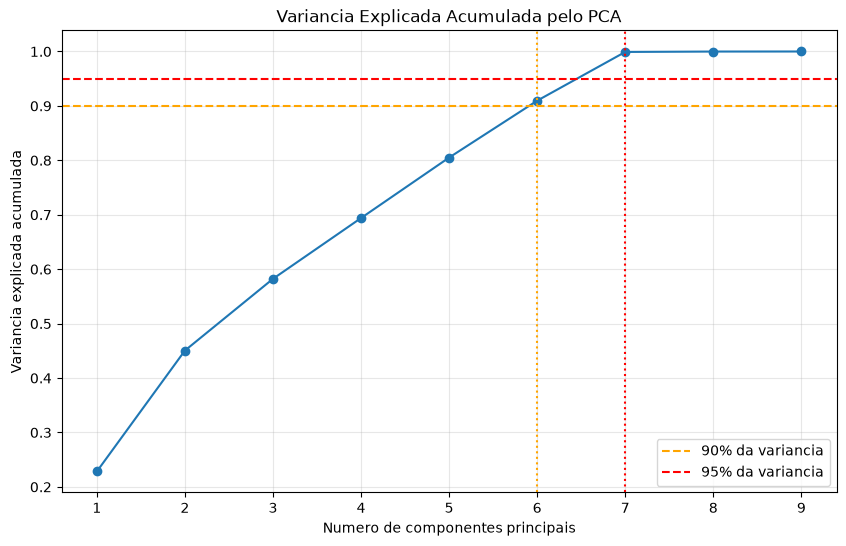

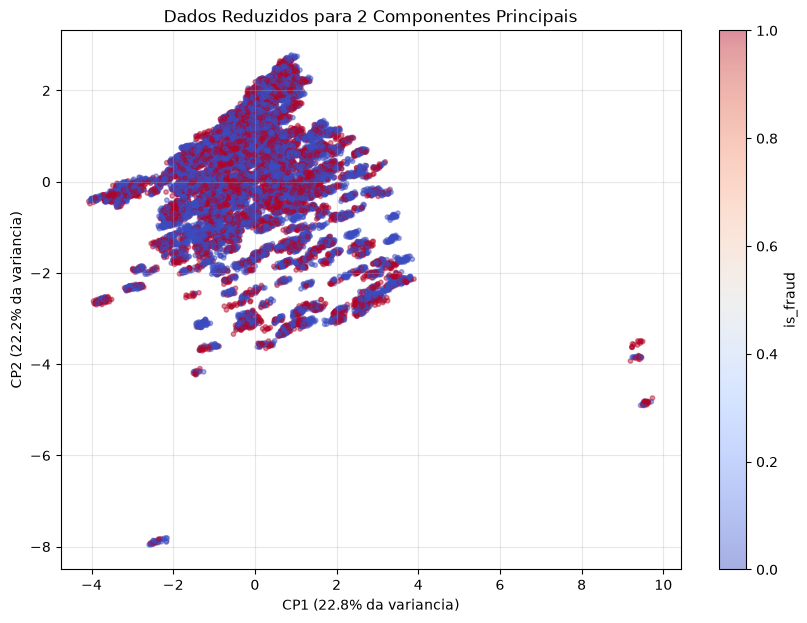

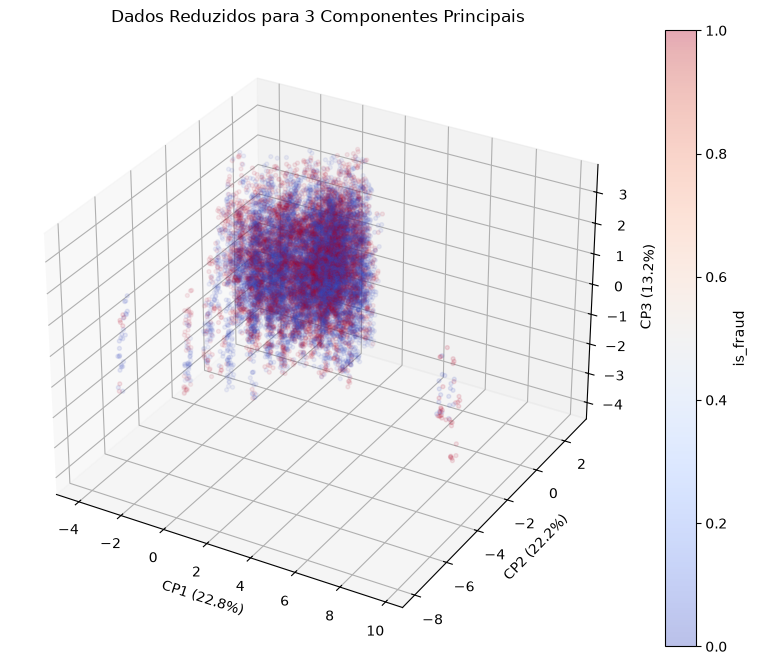

,PC1,PC2,is_fraud
0,-0.908048,0.664031,0
1,3.745247,-1.683017,0
2,1.995139,-1.685696,0
3,2.987973,-1.337113,0
4,-0.349833,1.136888,0


In [11]:
# Reducao de dimensionalidade com PCA

try:
    df_pca = df.copy()
    print("Usando DataFrame ja carregado: df")
except NameError:
    df_pca = pd.read_csv("data/dados_limpos.csv")
    print("DataFrame df nao encontrado. Carregando data/dados_limpos.csv")

# Remove alvo, identificadores e variaveis que nao devem orientar a reducao.
colunas_excluir = [
    "is_fraud", "unix_time", "cc_num", "zip", "merch_zipcode",
    "trans_date_trans_time", "dob"
]

X_numerico = df_pca.select_dtypes(include=[np.number]).drop(
    columns=[col for col in colunas_excluir if col in df_pca.columns],
    errors="ignore"
)

X_numerico = X_numerico.fillna(X_numerico.median())
nomes_features = X_numerico.columns.tolist()

# PCA e sensivel a escala, entao o escalonamento deve acontecer antes da reducao.
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X_numerico)

print(f"Base usada no PCA: {X_escalonado.shape[0]} linhas e {X_escalonado.shape[1]} variaveis numericas.")
print("Variaveis consideradas:", nomes_features)

# PCA com todos os componentes para analisar a variancia explicada acumulada.
pca_completo = PCA()
pca_completo.fit(X_escalonado)

variancia_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
n_componentes_90 = np.argmax(variancia_acumulada >= 0.90) + 1
n_componentes_95 = np.argmax(variancia_acumulada >= 0.95) + 1

print(f"Componentes para explicar 90% da variancia: {n_componentes_90}")
print(f"Componentes para explicar 95% da variancia: {n_componentes_95}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o")
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% da variancia")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% da variancia")
plt.axvline(x=n_componentes_90, color="orange", linestyle=":")
plt.axvline(x=n_componentes_95, color="red", linestyle=":")
plt.title("Variancia Explicada Acumulada pelo PCA")
plt.xlabel("Numero de componentes principais")
plt.ylabel("Variancia explicada acumulada")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Reducao para 2D e 3D.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_escalonado)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_escalonado)

cores = df_pca["is_fraud"].to_numpy() if "is_fraud" in df_pca.columns else None

# Amostragem para deixar os graficos leves. Se existir is_fraud, preserva todos os casos de fraude.
rng = np.random.default_rng(42)
limite_plot = 20000
todos_indices = np.arange(len(X_pca_2d))

if cores is not None:
    indices_fraude = todos_indices[cores == 1]
    indices_nao_fraude = todos_indices[cores == 0]
    qtd_nao_fraude = max(0, limite_plot - len(indices_fraude))
    indices_nao_fraude = rng.choice(
        indices_nao_fraude,
        size=min(qtd_nao_fraude, len(indices_nao_fraude)),
        replace=False
    )
    indices_plot = np.concatenate([indices_fraude, indices_nao_fraude])
else:
    indices_plot = rng.choice(
        todos_indices,
        size=min(limite_plot, len(todos_indices)),
        replace=False
    )

rng.shuffle(indices_plot)
cores_plot = cores[indices_plot] if cores is not None else None

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_2d[indices_plot, 0],
    X_pca_2d[indices_plot, 1],
    c=cores_plot,
    cmap="coolwarm",
    alpha=0.45,
    s=10
)
plt.title("Dados Reduzidos para 2 Componentes Principais")
plt.xlabel(f"CP1 ({pca_2d.explained_variance_ratio_[0]:.1%} da variancia)")
plt.ylabel(f"CP2 ({pca_2d.explained_variance_ratio_[1]:.1%} da variancia)")
plt.grid(alpha=0.3)

if cores is not None:
    plt.colorbar(scatter, label="is_fraud")

plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
grafico_3d = ax.scatter(
    X_pca_3d[indices_plot, 0],
    X_pca_3d[indices_plot, 1],
    X_pca_3d[indices_plot, 2],
    c=cores_plot,
    cmap="coolwarm",
    alpha=0.35,
    s=8
)
ax.set_title("Dados Reduzidos para 3 Componentes Principais")
ax.set_xlabel(f"CP1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"CP2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"CP3 ({pca_3d.explained_variance_ratio_[2]:.1%})")

if cores is not None:
    fig.colorbar(grafico_3d, ax=ax, label="is_fraud")

plt.show()

# DataFrames com os dados reduzidos, para usar nas proximas etapas.
df_pca_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])

if cores is not None:
    df_pca_2d["is_fraud"] = cores
    df_pca_3d["is_fraud"] = cores

df_pca_2d.head()


##### Interpretação dos Resultados:

Nesta etapa, foi aplicada a Análise de Componentes Principais (PCA) sobre os dados numéricos já limpos e escalonados. A base utilizada possui **1.296.675 registros** e **9 variáveis numéricas**: `amt`, `lat`, `long`, `city_pop`, `merch_lat`, `merch_long`, `trans_hour`, `trans_day_of_week` e `age`.

O gráfico de variância explicada acumulada mostra quanto da informação original dos dados é preservada à medida que aumentamos o número de componentes principais. Observa-se que:

- Com **6 componentes principais**, o modelo preserva aproximadamente **90% da variância** dos dados.
- Com **7 componentes principais**, o modelo preserva aproximadamente **95% da variância** dos dados.

Isso indica que é possível reduzir a dimensionalidade da base de 9 variáveis para 6 ou 7 componentes, mantendo a maior parte da informação original. Para uma redução mais compacta, 6 componentes já representam bem os dados. Para preservar mais informação, 7 componentes são uma escolha mais segura.

Nas visualizações em 2D e 3D, os dados foram projetados nos primeiros componentes principais. No gráfico 2D, os dois primeiros componentes explicam cerca de **45% da variância total** dos dados, sendo **22,8% pelo CP1** e **22,2% pelo CP2**. Já no gráfico 3D, os três primeiros componentes explicam aproximadamente **58,2% da variância total**, somando **22,8% do CP1**, **22,2% do CP2** e **13,2% do CP3**.

As cores representam a variável `is_fraud`, em que `0` indica transações não fraudulentas e `1` indica transações fraudulentas. Visualmente, percebe-se que as transações fraudulentas aparecem misturadas às transações normais, sem uma separação linear clara apenas com os primeiros componentes principais. Isso sugere que a fraude não é facilmente distinguida somente por uma projeção PCA em 2D ou 3D.

Mesmo assim, o PCA é útil porque reduz a quantidade de variáveis e cria uma representação mais compacta dos dados, que pode ser utilizada nas próximas etapas, como algoritmos de agrupamento ou detecção de anomalias.

# Aplicando *K-MEANS* e *DB-SCAN*

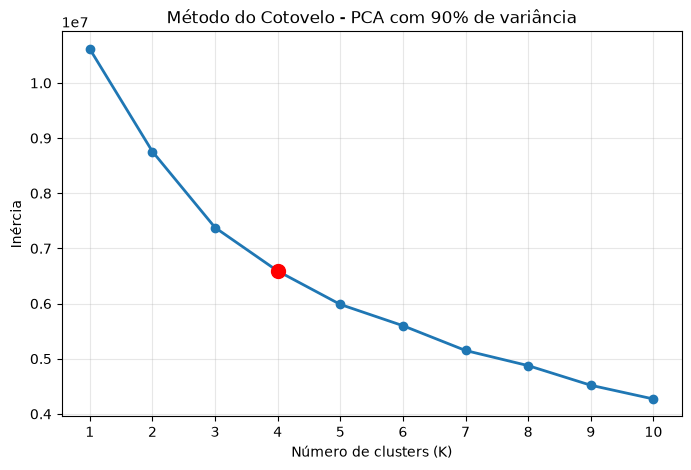

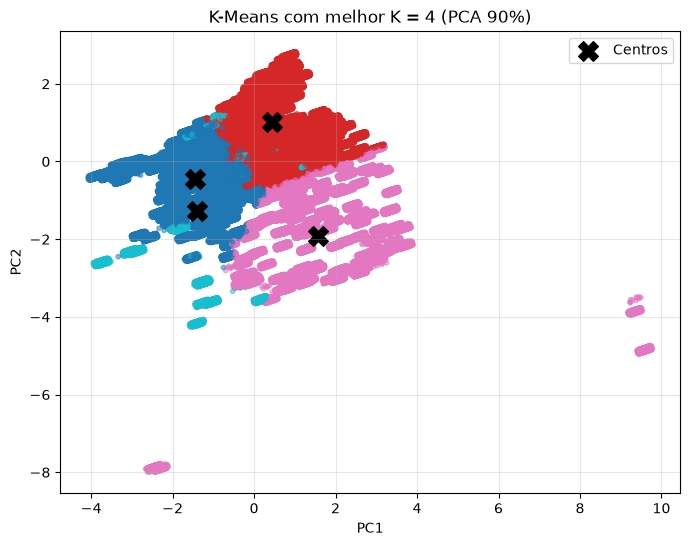

Melhor K encontrado pelo método do cotovelo: 4
Número de amostras por cluster: [394726 641925 219195  40829]


In [12]:
# Reutilizando os dados já escalonados e o número de componentes calculados anteriormente.
# para aplicar PCA com 90% de variância explicada.

if 'X_escalonado' in globals():
    X_base = X_escalonado
else:
    X_base = scaler.fit_transform(X_numerico)

if 'n_componentes_90' in globals():
    n_componentes = int(n_componentes_90)
else:
    n_componentes = 0.90

pca_90 = PCA(n_components=n_componentes, random_state=42)
X_pca_90 = pca_90.fit_transform(X_base)

# Método do cotovelo para encontrar o melhor K
inercia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_90)
    inercia.append(kmeans.inertia_)

# Identificando o ponto de cotovelo pela maior distância até a reta entre o primeiro e o último ponto
x = np.array(k_values)
y = np.array(inercia)
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

p1 = (x_norm[0], y_norm[0])
p2 = (x_norm[-1], y_norm[-1])

distances = []
for xi, yi in zip(x_norm, y_norm):
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    if dx == 0 and dy == 0:
        dist = 0
    else:
        dist = abs(dy * xi - dx * yi + p2[0] * p1[1] - p2[1] * p1[0]) / np.sqrt(dx**2 + dy**2)
    distances.append(dist)

knee_idx = np.argmax(distances[1:-1]) + 1
melhor_k = int(x[knee_idx])

plt.figure(figsize=(8, 5))
plt.plot(k_values, inercia, marker='o', linewidth=2)
plt.scatter(melhor_k, inercia[melhor_k - 1], color='red', s=100, zorder=5)
plt.title('Método do Cotovelo - PCA com 90% de variância')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X_pca_90)

# Gráfico dos clusters no espaço PCA (K-Means)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_90[:, 0], X_pca_90[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centros')
plt.title(f'K-Means com melhor K = {melhor_k} (PCA 90%)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Melhor K encontrado pelo método do cotovelo: {melhor_k}')
print(f'Número de amostras por cluster: {np.bincount(labels)}')


O valor ideal de \(K\) foi determinado por meio do método do cotovelo, que analisa a variação da inércia em função do número de clusters. Para conferir maior rigor matemático à escolha do "ponto de inflexão", utilizou-se o critério da maior distância ortogonal em relação à reta que conecta o primeiro e o último ponto da curva. Esse método identifica com precisão onde a redução da inércia perde expressividade, estabelecendo o melhor compromisso entre a complexidade do modelo e a qualidade do agrupamento.


Executando DBSCAN na amostra 1/3 (1%)...

Executando DBSCAN na amostra 2/3 (1%)...

Executando DBSCAN na amostra 3/3 (1%)...

Melhor DBSCAN (3 amostras aleatórias de 1%): eps=0.1000, min_samples=3, silhouette=0.9876
Clusters encontrados (excl. ruído): 2, pontos rotulados como ruído: 12960


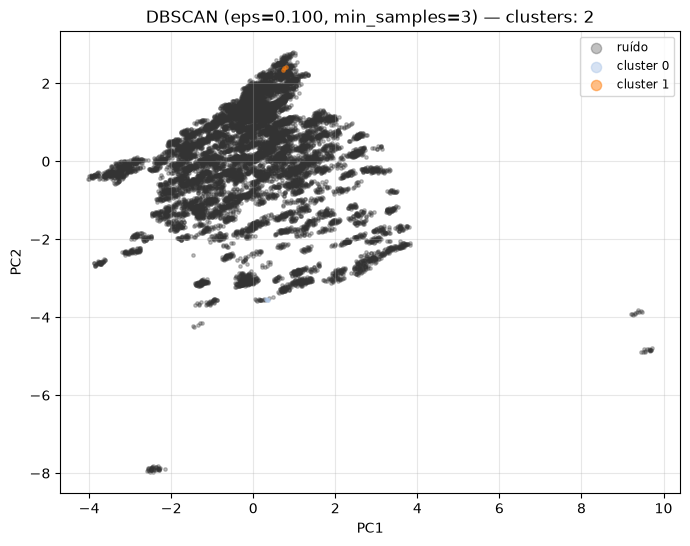


Rótulos salvos com sucesso no DataFrame 'df_pca_2d_amostra' (12966 linhas).

Top 5 configurações DBSCAN por silhouette (se disponíveis):
     sample   eps  min_samples  n_clusters  noise_ratio  silhouette
488       3  0.10            3           2     0.999537    0.987628
17        1  0.15            4           4     0.998766    0.941551
8         1  0.10            3           6     0.998535    0.941423
257       2  0.15            4           3     0.999075    0.940086
26        1  0.20            5           5     0.997995    0.897357


In [13]:
# Três amostragens aleatórias de 1% dos dados para agilizar o DBSCAN
rng_dbscan = np.random.default_rng(42)
size_amostra = max(100, int(len(X_pca_90) * 0.01))
indices_amostras = [
    rng_dbscan.choice(len(X_pca_90), size=size_amostra, replace=False)
    for _ in range(3)
]
X_pca_90_amostras = [X_pca_90[idx] for idx in indices_amostras]

# set dos parâmetros 
eps_values = np.linspace(0.05, 1.5, 30)
min_samples_values = range(3, 11)

best_score = -1
best_params = None
best_labels = None
best_sample_indices = None # Rastreia os índices da amostra vencedora
best_X_sample = None # Rastreia os dados exatos da amostra vencedora para o plot
results = []

for sample_idx, X_sample in enumerate(X_pca_90_amostras, start=1):
    print(f'\nExecutando DBSCAN na amostra {sample_idx}/3 (1%)...')
    for eps in eps_values:
        for ms in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', n_jobs=-1)
            lab = db.fit_predict(X_sample)
            mask = lab != -1
            n_clusters = len(set(lab[mask])) if mask.any() else 0
            noise_ratio = (lab == -1).sum() / len(lab)
            if n_clusters <= 1:
                results.append({'sample': sample_idx, 'eps': float(eps), 'min_samples': int(ms), 'n_clusters': int(n_clusters), 'noise_ratio': float(noise_ratio), 'silhouette': None})
                continue
            try:
                score = silhouette_score(X_sample[mask], lab[mask])
            except Exception:
                score = None
            results.append({'sample': sample_idx, 'eps': float(eps), 'min_samples': int(ms), 'n_clusters': int(n_clusters), 'noise_ratio': float(noise_ratio), 'silhouette': score})
            if score is not None and score > best_score:
                best_score = score
                best_params = (float(eps), int(ms))
                best_labels = lab.copy()
                best_sample_indices = indices_amostras[sample_idx - 1] # Salva qual foi a amostra
                best_X_sample = X_sample.copy() # Salva os dados para o gráfico

if best_params is None:
    print('Nenhuma configuração válida de DBSCAN encontrou mais de um cluster. Considere ajustar os intervalos de busca.')
else:
    beps, bms = best_params
    print(f'\nMelhor DBSCAN (3 amostras aleatórias de 1%): eps={beps:.4f}, min_samples={bms}, silhouette={best_score:.4f}')
    n_clusters_best = len(set(best_labels)) - (1 if -1 in best_labels else 0)
    noise_best = (best_labels == -1).sum()
    print(f'Clusters encontrados (excl. ruído): {n_clusters_best}, pontos rotulados como ruído: {noise_best}')

    # Plot DBSCAN result (usando primeiros 2 componentes do PCA)
    plt.figure(figsize=(8, 6))
    if best_labels is not None:
        unique_labels = sorted(set(best_labels))
        colors = [plt.cm.tab20(i % 20) for i in range(len(unique_labels))]
        for lab_val, col in zip(unique_labels, colors):
            mask_lab = best_labels == lab_val
            if lab_val == -1:
                # Usando best_X_sample em vez do último X_sample do loop
                plt.scatter(best_X_sample[mask_lab, 0], best_X_sample[mask_lab, 1], c=[(0.2, 0.2, 0.2)], alpha=0.3, s=6, label='ruído')
            else:
                plt.scatter(best_X_sample[mask_lab, 0], best_X_sample[mask_lab, 1], c=[col], alpha=0.5, s=6, label=f'cluster {lab_val}')
        plt.title(f'DBSCAN (eps={beps:.3f}, min_samples={bms}) — clusters: {n_clusters_best}')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.legend(markerscale=3, fontsize='small')
        plt.grid(True, alpha=0.3)
        plt.show()

    # Salva rótulos em um DataFrame específico da amostra vencedora
    if 'df_pca_2d' in globals() and best_labels is not None:
        # Filtra o dataframe principal para ter apenas as linhas que foram testadas
        df_pca_2d_amostra = df_pca_2d.iloc[best_sample_indices].copy()
        
        # Agora a atribuição funciona pois ambos possuem o mesmo tamanho
        df_pca_2d_amostra['dbscan_label'] = best_labels
        print(f"\nRótulos salvos com sucesso no DataFrame 'df_pca_2d_amostra' ({len(df_pca_2d_amostra)} linhas).")

# Registro sumarizado das melhores combinações
results_df = pd.DataFrame(results)
# mostra top 5 por silhouette
if not results_df.empty:
    top5 = results_df.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False).head(5)
    print('\nTop 5 configurações DBSCAN por silhouette (se disponíveis):')
    print(top5[['sample','eps','min_samples','n_clusters','noise_ratio','silhouette']])

O DBSCAN (Density-Based Spatial Clustering of Applications with Noise) é um algoritmo de clustering baseado em densidade que identifica regiões de alta concentração de pontos como clusters e rotula pontos isolados como ruído. Ele define um cluster a partir de dois parâmetros principais:

- `eps`: distância máxima para considerar pontos vizinhos.
- `min_samples`: número mínimo de pontos dentro da vizinhança para um ponto ser considerado núcleo.

A principal diferença em relação ao K-Means é que o DBSCAN não exige um número pré-definido de clusters e é capaz de encontrar formas de clusters arbitrárias, além de separar automaticamente pontos de ruído. Já o K-Means busca particionar os dados em `K` grupos esféricos de tamanho semelhante e tende a funcionar melhor quando os clusters têm forma aproximadamente circular e estão bem separados.

Para este experimento, usamos o mesmo conjunto de dados reduzido pelo PCA com 90% da variância preservada e fizemos três amostras aleatórias de 1% dos dados para acelerar o tuning do DBSCAN. A ideia é testar valores de `eps` e `min_samples` em amostras representativas, buscar a configuração que maximiza a silhueta e interpretar tanto a estrutura de agrupamento quanto a presença de ruído.

Interpretação do experimento:

- Se o DBSCAN encontrar poucos clusters e muito ruído, isso sugere que os dados não formam grupos densos claros na projeção PCA usada.
- Se o DBSCAN identificar clusters bem definidos com baixo ruído, indica que há padrões locais de densidade que podem ser úteis para segmentação ou detecção de anomalias.
- Como os dados são transações financeiras com fraude rara, o DBSCAN pode ser especialmente interessante para capturar regiões de anomalia e separar transações isoladas que não pertencem a grupos densos típicos.

# Análise de clusters

In [ ]:
def dunn_index(X, labels):
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]
    
    unique_labels = np.unique(labels_filtered)
    if len(unique_labels) < 2:
        return np.nan
        
    dist_matrix = pairwise_distances(X_filtered)
    
    max_intra = 0
    min_inter = np.inf
    
    for i in unique_labels:
        mask_i = (labels_filtered == i)
        if np.sum(mask_i) > 1:
            intra_dists = dist_matrix[mask_i][:, mask_i]
            max_intra = max(max_intra, np.max(intra_dists))
        
        for j in unique_labels:
            if i < j:
                mask_j = (labels_filtered == j)
                inter_dists = dist_matrix[mask_i][:, mask_j]
                min_inter = min(min_inter, np.min(inter_dists))
                
    if max_intra == 0:
        return np.nan
        
    return min_inter / max_intra

kmeans_labels_amostra = kmeans_final.predict(best_X_sample)
dbscan_labels_amostra = best_labels

def calcular_metricas(nome_modelo, X, labels):
    mask = labels != -1
    X_valid = X[mask]
    labels_valid = labels[mask]
    
    if len(set(labels_valid)) > 1:
        sil = silhouette_score(X_valid, labels_valid)
        db = davies_bouldin_score(X_valid, labels_valid)
        dunn = dunn_index(X, labels)
    else:
        sil, db, dunn = np.nan, np.nan, np.nan
        
    qtd_ruido = np.sum(labels == -1)
    
    return {
        "Modelo": nome_modelo,
        "Clusters": len(set(labels_valid)),
        "Ruídos (-1)": qtd_ruido,
        "Silhouette": round(sil, 4) if not np.isnan(sil) else "N/A",
        "Davies-Bouldin": round(db, 4) if not np.isnan(db) else "N/A",
        "Dunn": round(dunn, 4) if not np.isnan(dunn) else "N/A"
    }

resultados = [
    calcular_metricas("K-Means", best_X_sample, kmeans_labels_amostra),
    calcular_metricas("DBSCAN", best_X_sample, dbscan_labels_amostra)
]

df_comparacao = pd.DataFrame(resultados)
print("### Comparação de Validação Interna ###\n")
print(df_comparacao.to_string(index=False))

### Comparação de Validação Interna ###

 Modelo  Clusters  Ruídos (-1)  Silhouette  Davies-Bouldin    Dunn
K-Means         4            0      0.2343          1.3520  0.0054
 DBSCAN         2        12960      0.9876          0.0139 45.6004


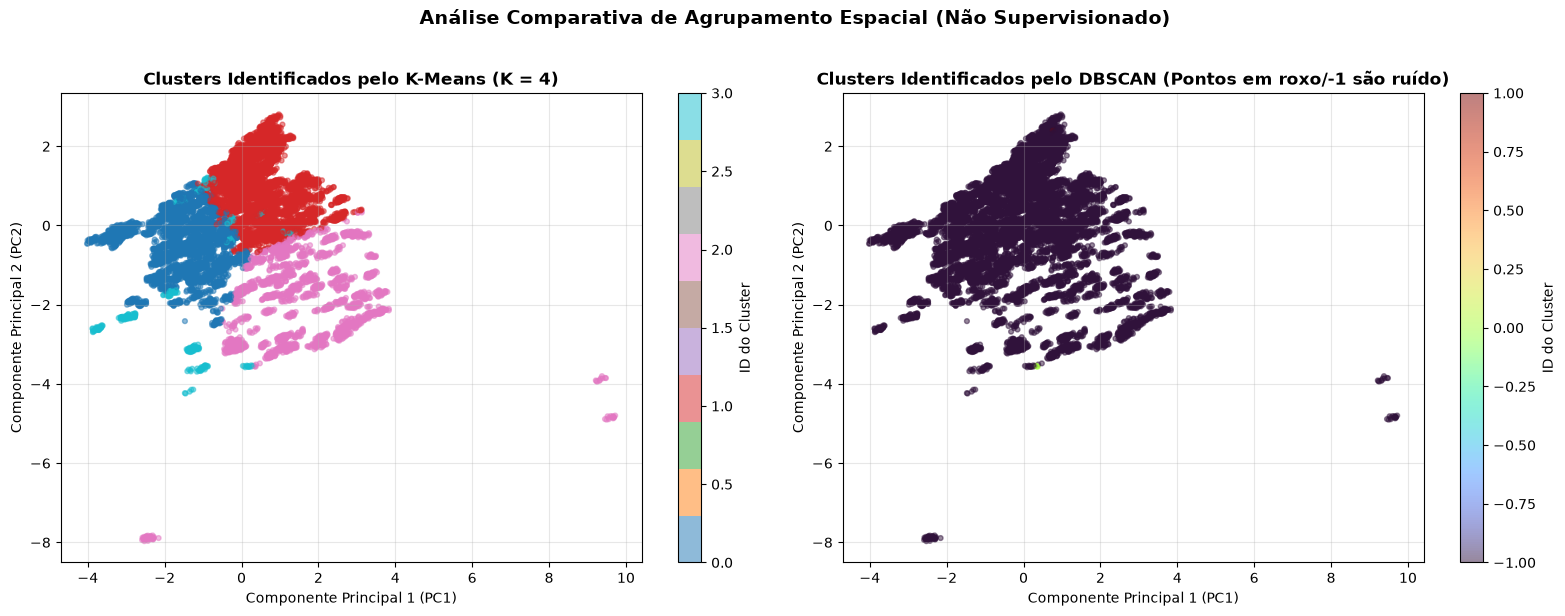

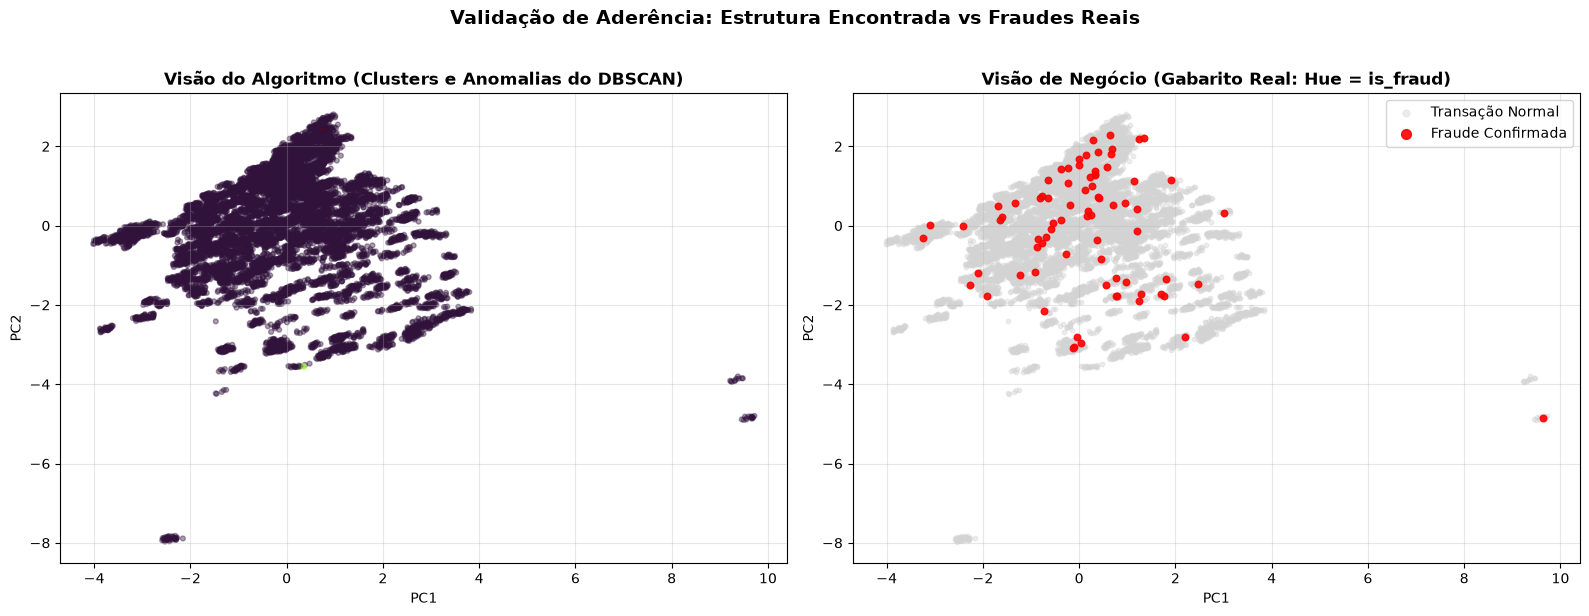

In [ ]:
df_analise = pd.DataFrame(best_X_sample[:, :2], columns=['PC1', 'PC2'])
df_analise['KMeans_Labels'] = kmeans_labels_amostra
df_analise['DBSCAN_Labels'] = dbscan_labels_amostra
df_analise['is_fraud'] = df_pca_2d.iloc[best_sample_indices]['is_fraud'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(df_analise['PC1'], df_analise['PC2'], 
                      c=df_analise['KMeans_Labels'], cmap='tab10', alpha=0.5, s=12)
ax1.set_title(f'Clusters Identificados pelo K-Means (K = {melhor_k})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Componente Principal 1 (PC1)')
ax1.set_ylabel('Componente Principal 2 (PC2)')
ax1.grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=ax1, label='ID do Cluster')

scatter2 = ax2.scatter(df_analise['PC1'], df_analise['PC2'], 
                      c=df_analise['DBSCAN_Labels'], cmap='turbo', alpha=0.5, s=12)
ax2.set_title('Clusters Identificados pelo DBSCAN (Pontos em roxo/-1 são ruído)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Componente Principal 1 (PC1)')
ax2.set_ylabel('Componente Principal 2 (PC2)')
ax2.grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=ax2, label='ID do Cluster')

plt.suptitle('Análise Comparativa de Agrupamento Espacial (Não Supervisionado)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

scatter_db = ax3.scatter(df_analise['PC1'], df_analise['PC2'], 
                         c=df_analise['DBSCAN_Labels'], cmap='turbo', alpha=0.4, s=12)
ax3.set_title('Visão do Algoritmo (Clusters e Anomalias do DBSCAN)', fontsize=12, fontweight='bold')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.grid(True, alpha=0.3)

fraudes = df_analise[df_analise['is_fraud'] == 1]
normais = df_analise[df_analise['is_fraud'] == 0]

ax4.scatter(normais['PC1'], normais['PC2'], c='lightgray', alpha=0.4, s=10, label='Transação Normal')
ax4.scatter(fraudes['PC1'], fraudes['PC2'], c='red', alpha=0.9, s=22, label='Fraude Confirmada', zorder=5)
ax4.set_title('Visão de Negócio (Gabarito Real: Hue = is_fraud)', fontsize=12, fontweight='bold')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper right', markerscale=1.5)

plt.suptitle('Validação de Aderência: Estrutura Encontrada vs Fraudes Reais', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

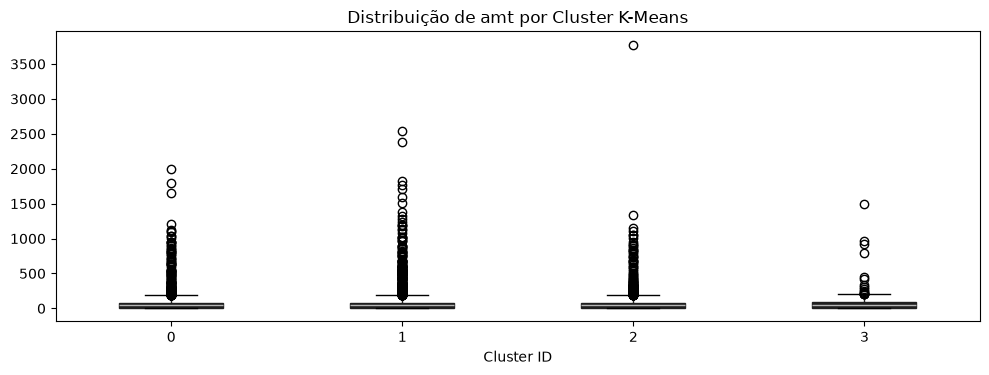

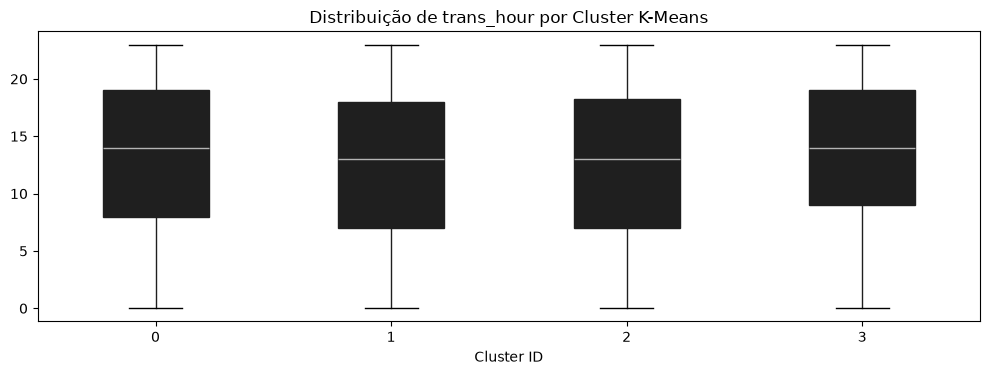

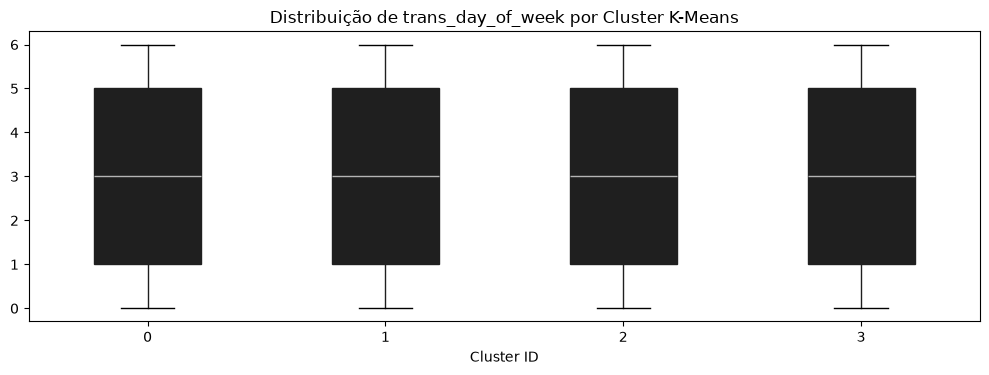

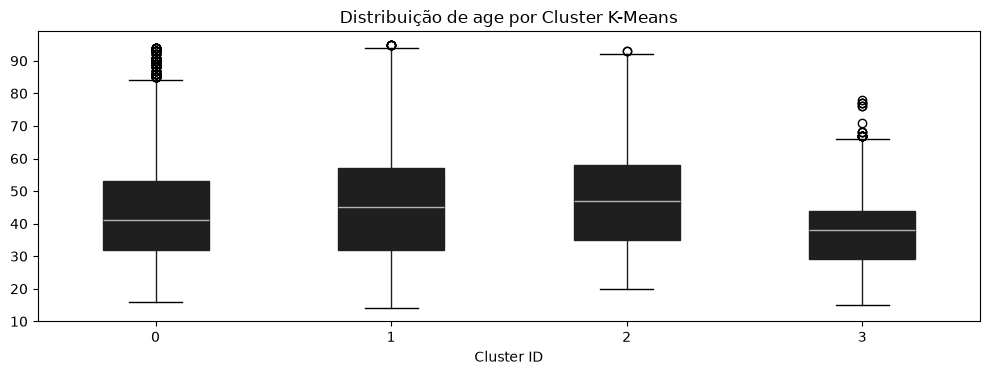

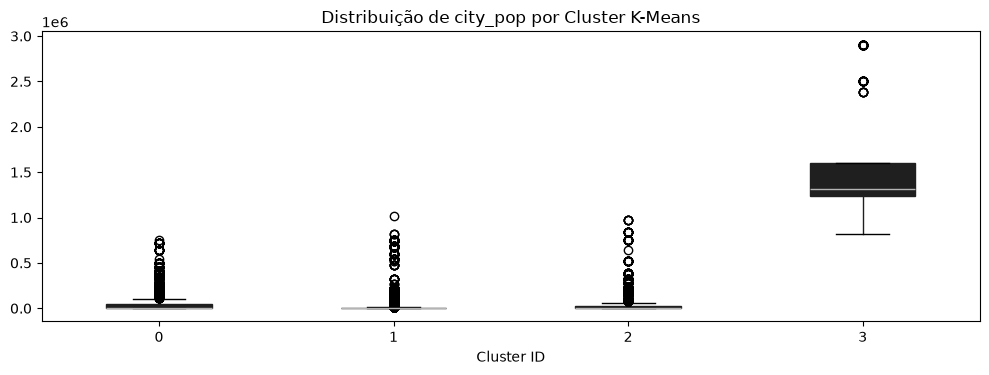

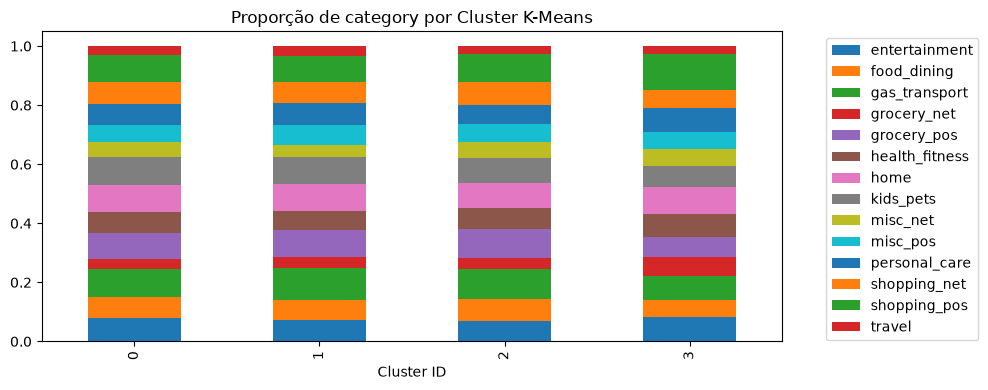

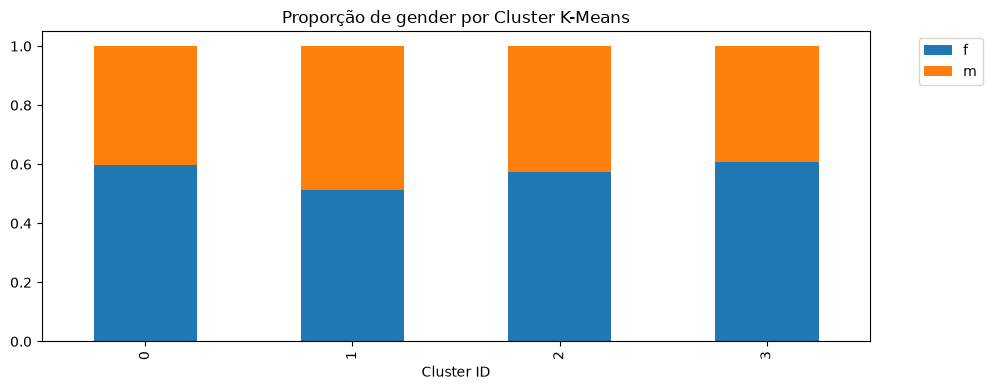

In [ ]:
df_com_labels = df.iloc[best_sample_indices].copy()
df_com_labels['KMeans_Labels'] = kmeans_labels_amostra

colunas_analise = ['amt', 'trans_hour', 'trans_day_of_week', 'age', 'city_pop', 'category', 'gender']

for col in colunas_analise:
    fig, ax = plt.subplots(figsize=(10, 4))
    
    if df_com_labels[col].dtype in ['float64', 'int64']:
        df_com_labels.boxplot(column=col, by='KMeans_Labels', ax=ax, grid=False, patch_artist=True)
        ax.set_title(f'Distribuição de {col} por Cluster K-Means')
        ax.set_xlabel('Cluster ID')
        plt.suptitle('')
    else:rmalizadas
        cross_tab = pd.crosstab(df_com_labels['KMeans_Labels'], df_com_labels[col], normalize='index')
        cross_tab.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Proporção de {col} por Cluster K-Means')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_xlabel('Cluster ID')

    plt.tight_layout()
    plt.show()


## Comparação dos Resultados e Validação

A análise comparativa entre as abordagens de agrupamento (K-Means e DBSCAN) revela que nenhum dos modelos foi capaz de isolar, de forma eficiente, a variável `is_fraud`. Embora o DBSCAN tenha apresentado métricas de validação interna numericamente superiores, essa performance é um artefato da metodologia de detecção de anomalias: o algoritmo rotulou 12.960 dos 12.966 registros como ruído (-1), isolando apenas uma fração mínima dos dados em clusters densos.

As métricas obtidas demonstram a divergência entre a eficácia matemática e a utilidade prática:

| Modelo | Clusters | Ruídos (-1) | Silhouette | Davies-Bouldin | Dunn |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **K-Means** | 4 | 0 | 0.2343 | 1.3520 | 0.0054 |
| **DBSCAN** | 2 | 12960 | 0.9876 | 0.0139 | 45.6004 |

### Discussão Crítica

* **DBSCAN:** As pontuações elevadas (Silhouette 0.98; Dunn 45.6) são enganosas no contexto do problema, pois refletem apenas a alta separação entre os poucos pontos densos encontrados, ignorando a vasta maioria do dataset descartada como ruído.
* **K-Means:** Apresentou métricas de validação interna insatisfatórias (Silhouette 0.23), o que sugere que o algoritmo foi forçado a dividir os dados em 4 grupos sem que houvesse uma estrutura natural de separação no espaço PCA.

### Análise Exploratória de Atributos

Para investigar o que guiou a formação dos grupos do K-Means, realizamos uma análise comparativa cruzando os clusters gerados com as variáveis originais. Observamos que o modelo atuou predominantemente como um classificador geodemográfico, e não como um detector de fraudes.

O destaque dessa segmentação foi a variável `city_pop` (população da cidade), onde o **Grupo 3** concentrou exclusivamente observações de grandes centros urbanos. Entretanto, ao confrontar essa segmentação com a variável `is_fraud` e o valor das transações (`amt`), notamos que o agrupamento não reflete padrões de fraude, mas sim o perfil regional dos usuários. Concluímos que a detecção de fraudes neste dataset exige abordagens que superem a análise puramente espacial, demandando a criação de novas variáveis baseadas em padrões temporais e comportamentais (Engenharia de Features).